In [1]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42657 sha256=40dab5c5289e210b285586f8f8544c27fc1008c9810fbd0a665612cbfa92d2a6
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [2]:
import pandas as pd
import numpy as np
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Final BRMCombined SampleData.xlsx to Final BRMCombined SampleData.xlsx


In [4]:
df = pd.read_excel('Final BRMCombined SampleData.xlsx', sheet_name=0)

In [6]:
from sklearn.preprocessing import StandardScaler

# Selecting only numeric columns from df
df_numeric = df.select_dtypes(include=[np.number])

# Dropping rows with any NaN values for KMO calculation
df_numeric = df_numeric.dropna()

# Dropping non-numeric, in case of, if any
df = df.select_dtypes(include=['float64', 'int64'])

# Filtering out columns with only one unique value (zero variance)
df_numeric = df_numeric.loc[:, df_numeric.nunique() > 1]

# Standardize
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [7]:
chi_sq, p = calculate_bartlett_sphericity(df)
print(f'Chi-square: {chi_sq}, P-value: {p}')

Chi-square: 878.6747502638859, P-value: 2.9978044574006208e-102


In [8]:
kmo_all, kmo_model = calculate_kmo(df_numeric)
print(f'KMO: {kmo_model}')

KMO: 0.7635258799210928


In [10]:
fa = FactorAnalyzer(rotation="varimax")
fa.fit(df)
eigen_values, _ = fa.get_eigenvalues()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [11]:
print("Eigenvalues:\n", eigen_values)

Eigenvalues:
 [6.78300873 2.65233998 1.58737174 1.46080355 1.00225284 0.89706132
 0.74046103 0.55501324 0.40696955 0.39909063 0.3464222  0.28296436
 0.24772289 0.19155505 0.15219382 0.13626164 0.10183697 0.05667044]


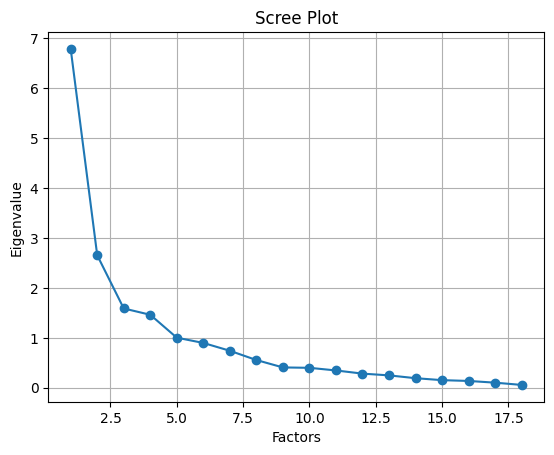

In [12]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(eigen_values)+1), eigen_values, marker='o')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.grid()
plt.show()

In [16]:
from factor_analyzer import FactorAnalyzer

fa = FactorAnalyzer(n_factors=4, rotation="varimax")
fa.fit(df)

loadings = fa.loadings_

# Converting to dataframe for readability
import pandas as pd
loadings_df = pd.DataFrame(loadings,
                          index=df.columns,
                          columns=['Factor1', 'Factor2', 'Factor3', 'Factor4'])

print(loadings_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


                                                     Factor1   Factor2  \
I believe that organic food currently sold in m...  0.038184  0.162370   
I have doubts towards the organic food labelling    0.112035  0.009571   
In my opinion, Organic food are healthier than ...  0.492574  0.313153   
In my view, organic food are free from pesticid...  0.566931  0.084549   
Organic food contains natural ingredients           0.642729  0.090813   
I fear that all the organic food claiming to be...  0.266280  0.057052   
I fear that I am paying more money for organic ...  0.430089 -0.015004   
I am happy to buy organic foods                     0.089873  0.513501   
I plan to consume organic foods                     0.254642  0.878998   
I would buy organic food products                   0.315991  0.841837   
I intend to purchase organic foods produce with...  0.250326  0.695036   
I intend to consume ethical products                0.827601  0.330631   
I plan to consume ethical products    

In [17]:
fa = FactorAnalyzer(n_factors=2, rotation="varimax")
fa.fit(df)

print("Factor Loadings:\n", fa.loadings_)
print("Factor Variance:\n", fa.get_factor_variance())
print("Factor Scores:\n", fa.transform(df))

Factor Loadings:
 [[ 0.03952492  0.56135519]
 [-0.06047166  0.67043171]
 [ 0.62832221  0.31182154]
 [ 0.55587414  0.25456397]
 [ 0.52720283  0.39780595]
 [ 0.02623828  0.71730061]
 [ 0.13780145  0.59675827]
 [ 0.5409879   0.10122582]
 [ 0.74756686  0.20722121]
 [ 0.75766532  0.20401854]
 [ 0.61100116  0.15053239]
 [ 0.53786311  0.62608908]
 [ 0.55556772  0.55406185]
 [ 0.59605623  0.54218405]
 [ 0.59647873 -0.24138387]
 [ 0.6080186  -0.23617029]
 [ 0.52025769  0.31074191]
 [ 0.59050592 -0.05940487]]
Factor Variance:
 (array([5.10360172, 3.28006251]), array([0.28353343, 0.1822257 ]), array([0.28353343, 0.46575912]))
Factor Scores:
 [[ 0.7016472   0.28271474]
 [-1.12988045 -0.70569266]
 [-1.23052964 -0.35686474]
 [-0.85453621  0.06869931]
 [-0.40625718 -1.21149341]
 [-0.54811118 -1.16910161]
 [ 0.38053628 -1.63290023]
 [ 0.36074371 -0.93758714]
 [-0.46079112 -0.6809716 ]
 [-1.24011182 -0.31521032]
 [ 0.7739382  -1.46087596]
 [ 0.45809892 -0.51515091]
 [-0.27098163 -0.68789095]
 [-0.97639

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [18]:
print("Shape:", df_numeric.shape)
print("\nUnique values:\n", df_numeric.nunique())
print("\nMissing values:\n", df_numeric.isnull().sum())
print("\nData types:\n", df_numeric.dtypes)

Shape: (73, 18)

Unique values:
 I believe that organic food currently sold in market are not really organic                                                         7
I have doubts towards the organic food labelling                                                                                    7
In my opinion, Organic food are healthier than the conventional food                                                                5
In my view, organic food are free from pesticides and other chemicals                                                               7
Organic food contains natural ingredients                                                                                           7
I fear that all the organic food claiming to be organic is not actually an organic food                                             7
I fear that I am paying more money for organic food                                                                                 7
I am happy to buy organic foo

In [19]:
!pip install seaborn

# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

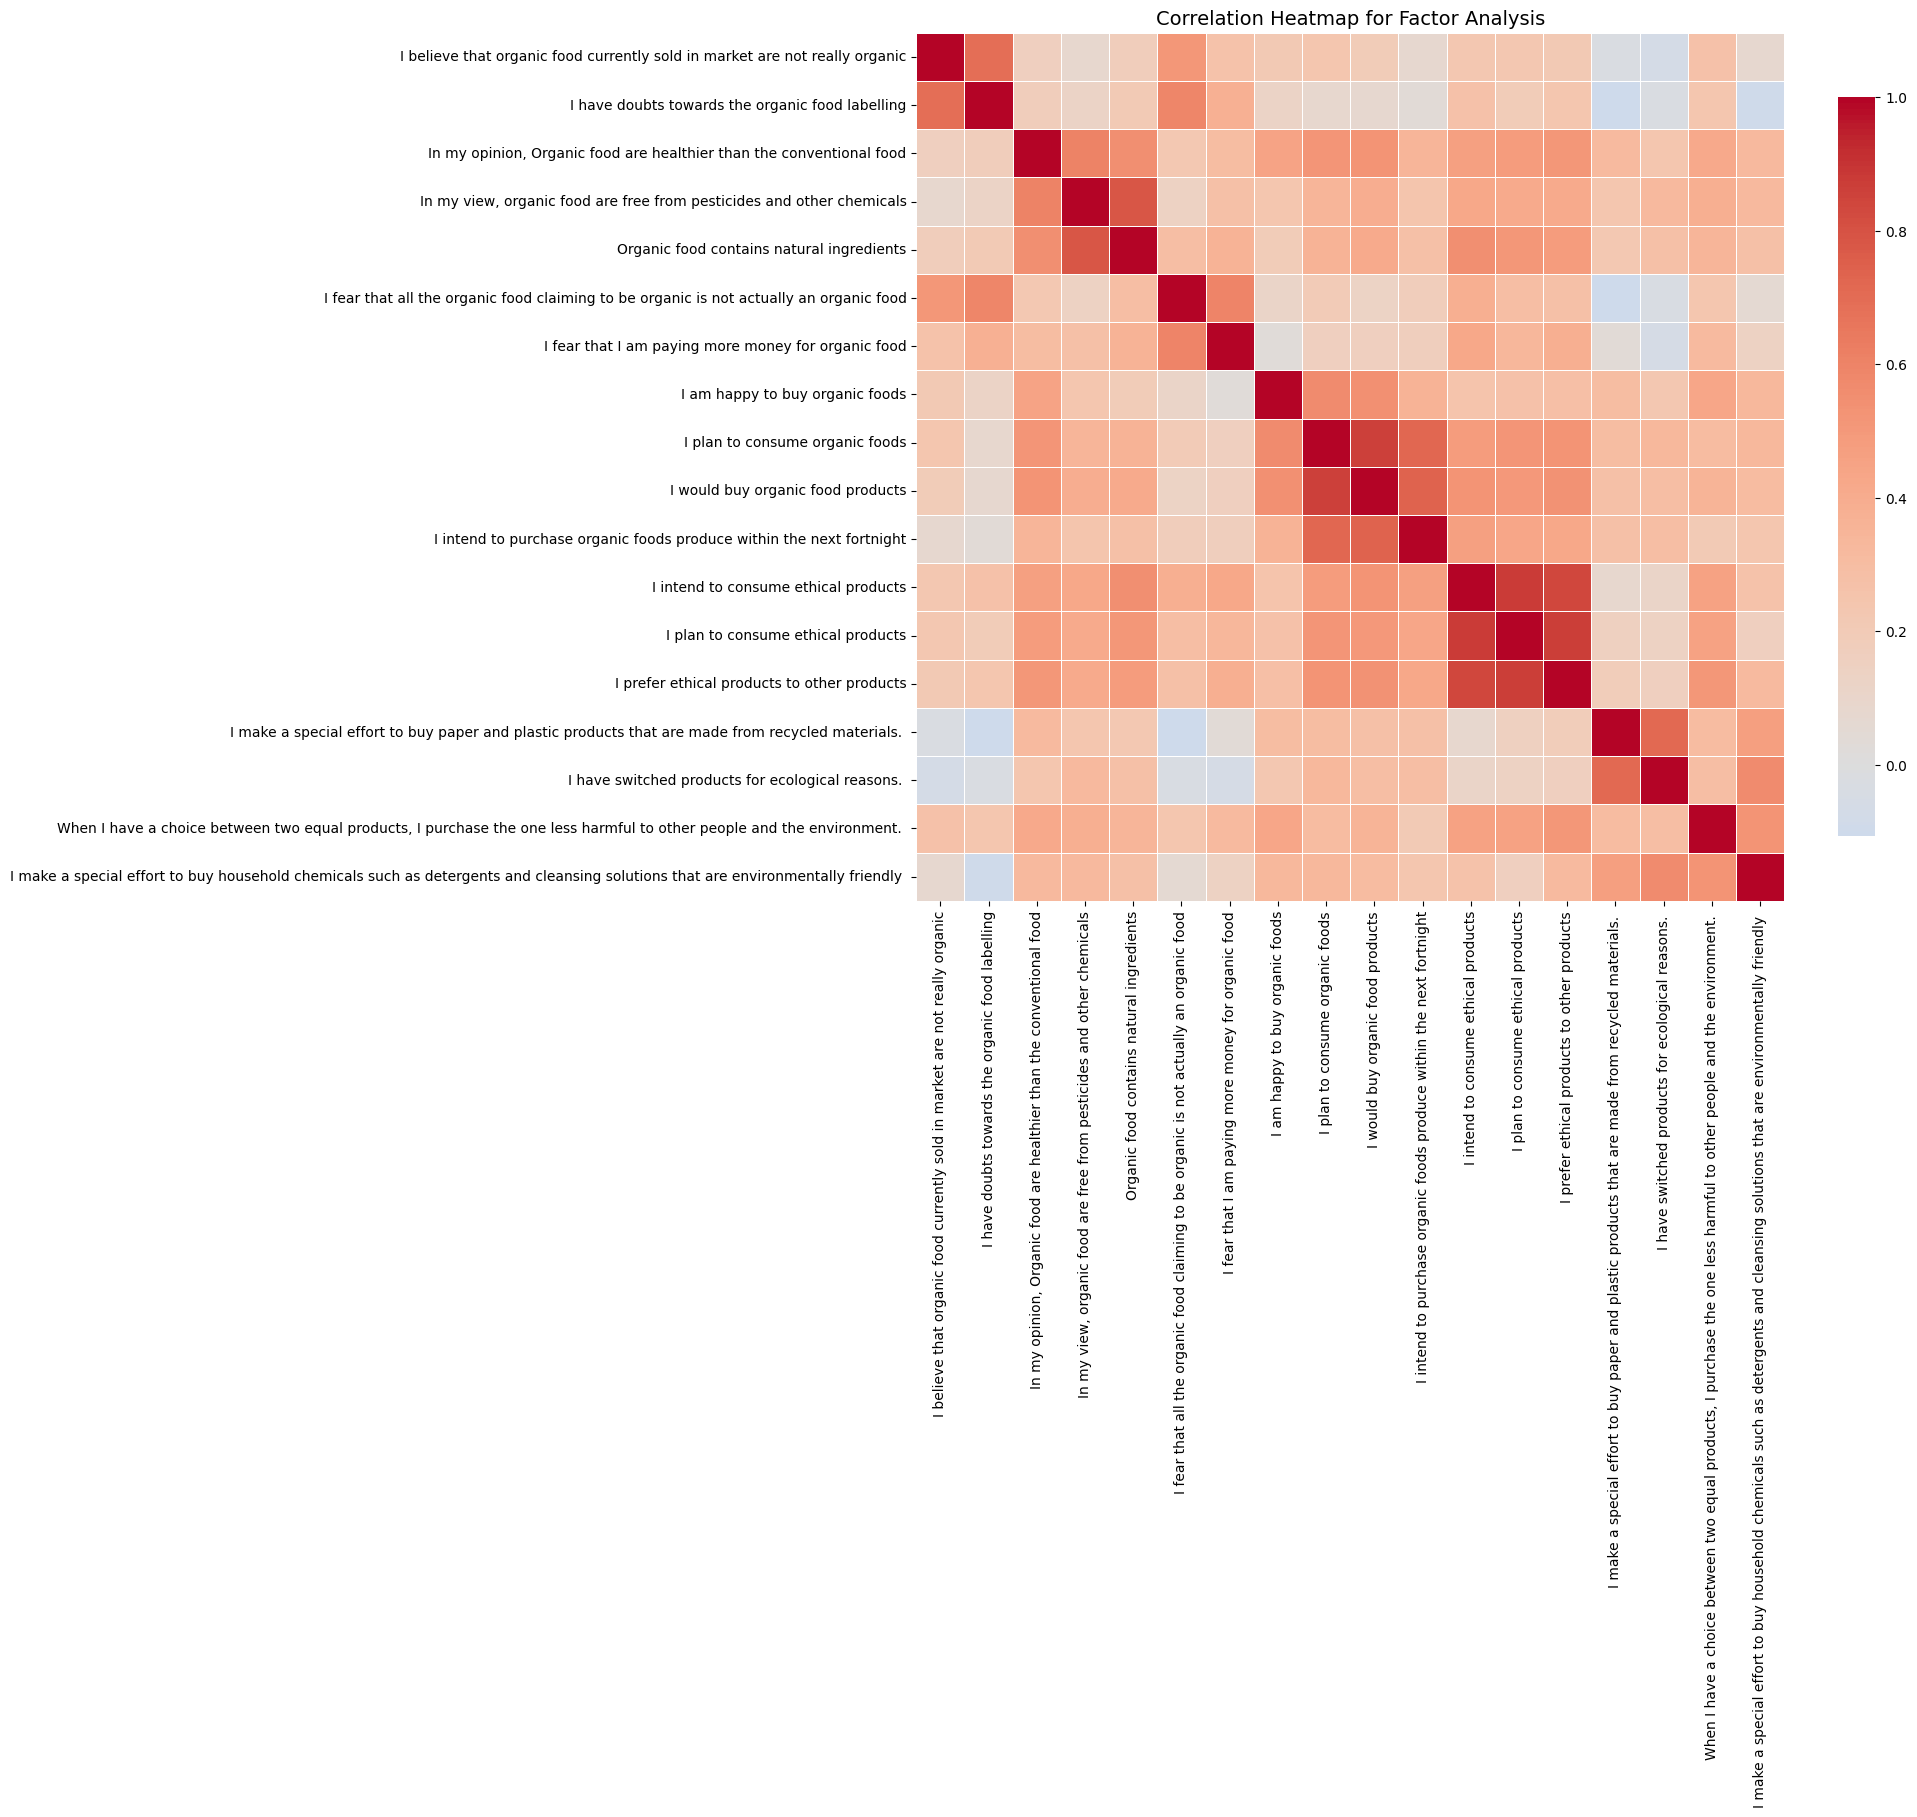

In [20]:
corr_matrix = df.corr()
# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',      # blue (-1) to red (+1)
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap for Factor Analysis", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

In [22]:
# Finding highly correlated pairs (>0.9) [CHECKING]
import numpy as np

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [
    (column, row, upper.loc[row, column])
    for column in upper.columns
    for row in upper.index
    if abs(upper.loc[row, column]) > 0.9
]

print("Highly correlated pairs (>0.9):")
for item in high_corr:
    print(item)

Highly correlated pairs (>0.9):


In [23]:
from factor_analyzer import FactorAnalyzer

# Fit FA with 4 factors + rotation !!!!!
fa = FactorAnalyzer(n_factors=4, rotation='varimax')
fa.fit(df_numeric)

# Factor Loadings
loadings = fa.loadings_
print("Factor Loadings:\n", loadings)

# Variance Explained
variance = fa.get_factor_variance()
print("\nFactor Variance:\n", variance)

# Factor Scores
scores = fa.transform(df_numeric)
print("\nFactor Scores:\n", scores)

Factor Loadings:
 [[ 3.81842039e-02  1.62369590e-01  1.11655051e-02  7.49173005e-01]
 [ 1.12035380e-01  9.57143623e-03 -4.14792391e-02  8.35439689e-01]
 [ 4.92574337e-01  3.13153351e-01  3.55161117e-01  1.54710340e-01]
 [ 5.66930501e-01  8.45490084e-02  4.12204103e-01  6.86407416e-02]
 [ 6.42728664e-01  9.08126918e-02  3.27333917e-01  1.68718445e-01]
 [ 2.66280169e-01  5.70515659e-02 -4.86871016e-02  7.01797238e-01]
 [ 4.30089196e-01 -1.50039475e-02  2.98455143e-02  4.51377858e-01]
 [ 8.98731157e-02  5.13500855e-01  3.23438051e-01  1.53721408e-01]
 [ 2.54641868e-01  8.78997556e-01  2.21683292e-01  9.63877106e-02]
 [ 3.15990553e-01  8.41837359e-01  2.06101166e-01  4.66298951e-02]
 [ 2.50325588e-01  6.95035972e-01  1.38449790e-01  8.01117866e-03]
 [ 8.27600981e-01  3.30631081e-01 -7.84340197e-03  1.97054102e-01]
 [ 8.07617366e-01  3.52784684e-01 -2.36662185e-04  1.22384374e-01]
 [ 7.73472439e-01  3.49260900e-01  9.01847968e-02  1.53931513e-01]
 [ 4.35647891e-02  1.90030023e-01  7.1794570

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [28]:
# [Refreshing next part importing, not necessary, just to double-check]

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
from factor_analyzer import FactorAnalyzer

fa = FactorAnalyzer(n_factors=4, rotation='varimax')
fa.fit(df_scaled)

loadings = pd.DataFrame(fa.loadings_,
                        index=df.columns,
                        columns=['Factor1','Factor2','Factor3','Factor4'])

print(loadings)

                                                     Factor1   Factor2  \
I believe that organic food currently sold in m...  0.038184  0.162370   
I have doubts towards the organic food labelling    0.112035  0.009571   
In my opinion, Organic food are healthier than ...  0.492574  0.313153   
In my view, organic food are free from pesticid...  0.566931  0.084549   
Organic food contains natural ingredients           0.642729  0.090813   
I fear that all the organic food claiming to be...  0.266280  0.057052   
I fear that I am paying more money for organic ...  0.430089 -0.015004   
I am happy to buy organic foods                     0.089873  0.513501   
I plan to consume organic foods                     0.254642  0.878998   
I would buy organic food products                   0.315991  0.841837   
I intend to purchase organic foods produce with...  0.250326  0.695036   
I intend to consume ethical products                0.827601  0.330631   
I plan to consume ethical products    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [30]:
drop_cols = [
    "I fear that I am paying more money...",
    "When I have a choice between two equal products...",
    "I make a special effort to buy paper and plastic...",
    "I have switched products for ecological reasons",
    "I make a special effort to buy household chemicals..."
]


In [31]:
# The 'drop_cols' list defined in a previous cell (wxemJ6NNlCwE)
drop_cols_partial = [
    "I fear that I am paying more money...",
    "When I have a choice between two equal products...",
    "I make a special effort to buy paper and plastic...",
    "I have switched products for ecological reasons",
    "I make a special effort to buy household chemicals..."
]

# Finding the exact column names from df that correspond to the partial names
drop_cols_exact = []
for partial_name in drop_cols_partial:
    # Remove '...' and strip whitespace for flexible matching
    cleaned_partial_name = partial_name.replace('...', '').strip()
    for full_col_name in df.columns:
        if cleaned_partial_name in full_col_name:
            drop_cols_exact.append(full_col_name)
            break # Found a match, move to the next partial name

df_cleaned = df.drop(columns=drop_cols_exact)

In [32]:
fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(df_cleaned)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(rotation='varimax', rotation_kwargs={})

In [33]:
loadings = pd.DataFrame(fa.loadings_,
                        index=df_cleaned.columns)

print(loadings)

                                                           0         1  \
I believe that organic food currently sold in m...  0.050415  0.152274   
I have doubts towards the organic food labelling    0.120865 -0.012390   
In my opinion, Organic food are healthier than ...  0.553381  0.385236   
In my view, organic food are free from pesticid...  0.629034  0.181940   
Organic food contains natural ingredients           0.709611  0.154068   
I fear that all the organic food claiming to be...  0.237713  0.065293   
I am happy to buy organic foods                     0.149101  0.558892   
I plan to consume organic foods                     0.296834  0.900905   
I would buy organic food products                   0.349006  0.872704   
I intend to purchase organic foods produce with...  0.271228  0.689363   
I intend to consume ethical products                0.795878  0.273036   
I plan to consume ethical products                  0.791869  0.285488   
I prefer ethical products to other pro

In [34]:
ev, v = fa.get_eigenvalues()
print(ev)

[5.81063286 1.9951839  1.43024518 1.11173404 0.68256436 0.49959895
 0.38157455 0.31670741 0.21760717 0.19244316 0.14947009 0.12583031
 0.08640803]


In [35]:
print(fa.get_factor_variance())

(array([3.4301169 , 2.84567871, 1.94130302]), array([0.26385515, 0.21889836, 0.149331  ]), array([0.26385515, 0.48275351, 0.63208451]))


In [36]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 6.1 MB/s eta 0:00:00


In [37]:
import pingouin as pg

In [38]:
factor1_partial_names = [
    "In my opinion, Organic food are healthier than ...",
    "In my view, organic food are free from pesticid...",
    "Organic food contains natural ingredients",
    "I intend to consume ethical products",
    "I plan to consume ethical products",
    "I prefer ethical products to other products"
]

factor1_cols_exact = []
for partial_name in factor1_partial_names:
    cleaned_partial_name = partial_name.replace('...', '').strip()
    found_match = False
    for full_col_name in df_cleaned.columns:
        if cleaned_partial_name in full_col_name:
            factor1_cols_exact.append(full_col_name)
            found_match = True
            break
    if not found_match and partial_name in df_cleaned.columns:
        factor1_cols_exact.append(partial_name) # Add if it's an exact match already

factor1 = df_cleaned[factor1_cols_exact]

pg.cronbach_alpha(factor1)

(np.float64(0.8941748242635166), array([0.852, 0.928]))

In [39]:
factor2_partial_names = [
    "I am happy to buy organic foods",
    "I plan to consume organic foods",
    "I would buy organic food products",
    "I intend to purchase organic foods produce with..."
]

factor2_cols_exact = []
for partial_name in factor2_partial_names:
    cleaned_partial_name = partial_name.replace('...', '').strip()
    found_match = False
    for full_col_name in df_cleaned.columns:
        if cleaned_partial_name in full_col_name:
            factor2_cols_exact.append(full_col_name)
            found_match = True
            break
    if not found_match and partial_name in df_cleaned.columns:
        factor2_cols_exact.append(partial_name) # Add if it's an exact match already

factor2 = df_cleaned[factor2_cols_exact]

pg.cronbach_alpha(factor2)

(np.float64(0.8737497393739015), array([0.819, 0.915]))

In [40]:
factor3_partial_names = [
    "I believe that organic food currently sold in m...",
    "I have doubts towards the organic food labelling",
    "I fear that all the organic food claiming to be..."
]

factor3_cols_exact = []
for partial_name in factor3_partial_names:
    cleaned_partial_name = partial_name.replace('...', '').strip()
    found_match = False
    for full_col_name in df_cleaned.columns:
        if cleaned_partial_name in full_col_name:
            factor3_cols_exact.append(full_col_name)
            found_match = True
            break
    if not found_match and partial_name in df_cleaned.columns:
        factor3_cols_exact.append(partial_name) # Add if it's an exact match already

factor3 = df_cleaned[factor3_cols_exact]

pg.cronbach_alpha(factor3)

(np.float64(0.8148333000598921), array([0.727, 0.878]))

In [41]:
X = df_scaled

pca = PCA(n_components=2)
df_pca = pca.fit_transform(X)

# Removed: df_train, df_test, y_train, y_test = train_test_split(df_pca, y, test_size=0.3, random_state=42)
# Removed: model = LogisticRegression()
# Removed: model.fit(df_train, y_train)
# Removed: y_pred = model.predict(df_test)

In [42]:
pca_loadings = pd.DataFrame(pca.components_, columns=df.columns, index=['PC1', 'PC2'])
print("PCA Loadings (Correlation between original features and principal components):")
display(pca_loadings.transpose())

PCA Loadings (Correlation between original features and principal components):


,PC1,PC2
I believe that organic food currently sold in market are not really organic,0.136710,0.337400
I have doubts towards the organic food labelling,0.123129,0.417502
"In my opinion, Organic food are healthier than the conventional food",0.279407,-0.043424
"In my view, organic food are free from pesticides and other chemicals",0.247354,-0.055056
Organic food contains natural ingredients,0.265559,0.040435
I fear that all the organic food claiming to be organic is not actually an organic food,0.160946,0.400500
I fear that I am paying more money for organic food,0.176685,0.307299
I am happy to buy organic foods,0.211361,-0.140956
I plan to consume organic foods,0.291907,-0.134712
I would buy organic food products,0.293929,-0.139199


In the table above, `PC1` and `PC2` represent our two principal components. The values under `PC1` and `PC2` for each original feature indicate the *loading* of that feature on the respective component.

A larger absolute value (positive or negative) signifies a stronger relationship and contribution of that original feature to the principal component. So we interpret what each principal component represents in terms of original data.

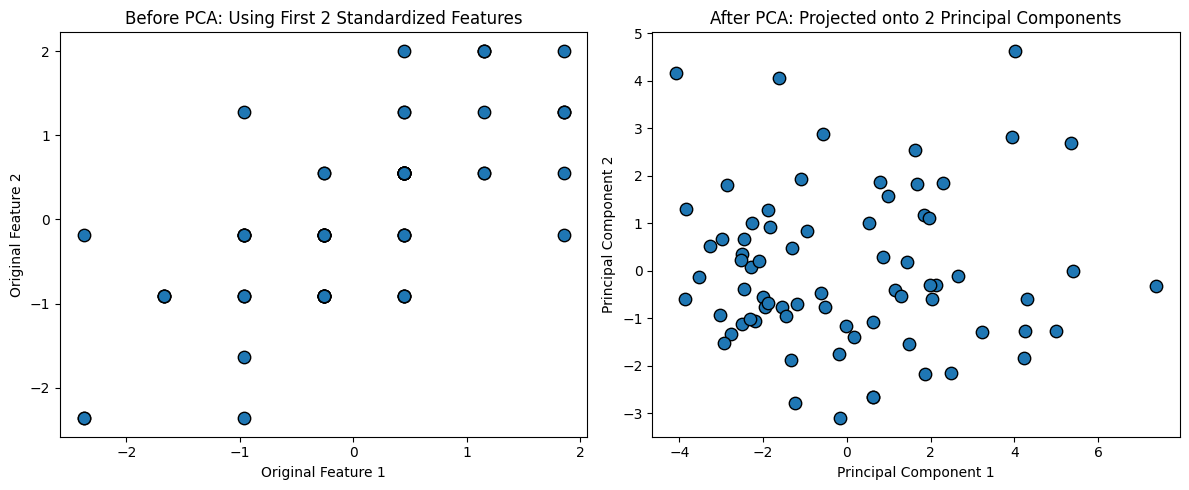

In [43]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], edgecolor='k', s=80)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')

plt.subplot(1, 2, 2)
plt.scatter(df_pca[:, 0], df_pca[:, 1], edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')

plt.tight_layout()
plt.show()